# Case Study 03 — NFLX, Q1 2024 earnings (grade day 2024-04-19)

**Type:** narrative head-fake  ·  **Ticker:** NFLX  ·  **asof:** 2024-04-19

Runs the full pipeline (`src/graph.py`) for this one signal-day and shows every stage. Companion to [`notebooks/walkthrough.ipynb`](walkthrough.ipynb), which explains the machinery in detail.

## Why this case

The overnight headlines were **unambiguously strong** — Netflix added 9.3M
subscribers against a ~5M estimate, beat on revenue and EPS, and expanded margins.
A naive read of the news flow says *bull, high conviction*.

The stock fell **9%**.

Two things in the same release did the damage: Netflix announced it would **stop
reporting quarterly subscriber numbers** from 2025 (the metric the whole bull
case had rested on), and guided Q2 revenue slightly light. This is the case where
narrative is confidently, expensively wrong.

And Kronos — which saw only prices through the 2024-04-18 close, on a stock that
had been grinding higher — *also* leaned bullish. So this day is a **double
miss**: both signals pointed up, the stock gapped down hard, and the realised
move fell straight through the bottom of Kronos's 5–95 envelope. It's the case
that tests coverage, not divergence.

In [1]:
import sys, os, json, shutil, pathlib
sys.path.insert(0, "..")
DEMO_LOG = pathlib.Path("_out/case_nflx_2024-04-19").resolve()
if DEMO_LOG.exists(): shutil.rmtree(DEMO_LOG)
DEMO_LOG.mkdir(parents=True)
os.environ["NARB_LOG_DIR"] = str(DEMO_LOG)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 100)
from src.llm import have_key
TICKER, ASOF = "NFLX", "2024-04-19"
print("real LLM:", have_key(), " (mock mode if False)")

real LLM: False  (mock mode if False)


## 1 · Data — the no-lookahead cut

source cache · 120 bars · 2023-10-26 -> 2024-04-18


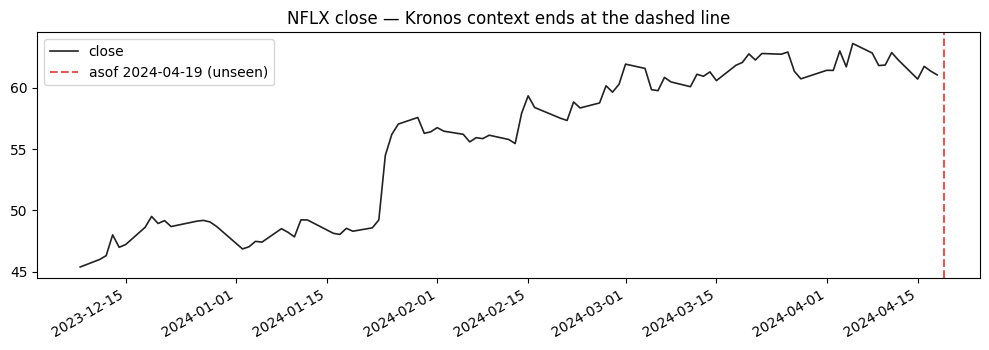

In [2]:
from src.data import load_context, load_actual
pl = load_context(TICKER, ASOF)
print(f"source {pl.source} · {len(pl.df)} bars · {pl.df.index.min().date()} -> {pl.last_context_date.date()}")
assert pl.last_context_date < pd.Timestamp(ASOF)
ax = pl.df["close"].iloc[-90:].plot(figsize=(10,3.6), color="#222", lw=1.2)
ax.axvline(pd.Timestamp(ASOF), color="#e45756", ls="--", label=f"asof {ASOF} (unseen)")
ax.set_title(f"{TICKER} close — Kronos context ends at the dashed line"); ax.legend(); plt.tight_layout()

## 2 · Structure — Kronos distribution

/Users/isaac/Desktop/narrative arb/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


median +1.13%  P(up) 80%  dispersion 1.58%  strength +0.71
5-95 envelope: [-1.59%, +3.97%]


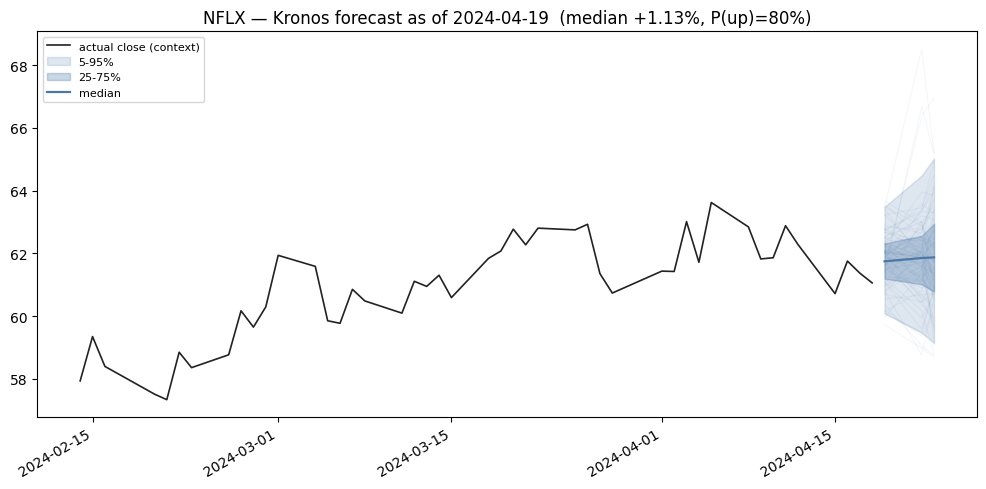

In [3]:
from src.kronos_infer import forecast, fan_chart
fc = forecast(pl)
q = fc.ret_quantiles()
print(f"median {fc.median_ret*100:+.2f}%  P(up) {fc.p_up:.0%}  dispersion {fc.std_ret*100:.2f}%  strength {fc.strength:+.2f}")
print("5-95 envelope:", f"[{q[0.05]*100:+.2f}%, {q[0.95]*100:+.2f}%]")
_ = fan_chart(fc, context_bars=45)

## 3 · Headlines sub-agent (price-blind)

In [4]:
from src.headlines_agent import get_headlines
hs = get_headlines(TICKER, ASOF)
print("mode:", hs["mode"], "| no_news:", hs["no_news"])
for n in hs["notes"]: print("  -", n)
pd.DataFrame(hs["headlines"])[["source","published","title"]] if hs["headlines"] else "— nothing material —"

mode: curated | no_news: False
  - loaded 4 curated headlines
  - dedupe: 4 -> 4
  - materiality: kept 4/4 — All four headlines are directly tied to Netflix's Q1 2024 earnings release and forward guidance: subscriber additions beating estimates, EPS beat, a material disclosure change (ending quarterly subscriber reporting starting 2025), and Q2 revenue guidance. These are core earnings/guidance items that are highly price-relevant for the next trading session.
  - FINAL: 4 material headlines


,source,published,title
0,CNBC,2024-04-18,"Netflix adds 9.3 million subscribers in Q1 2024, blowing past estimates"
1,Reuters,2024-04-18,Netflix beats on earnings; EPS $5.28 vs $4.52 expected
2,CNBC,2024-04-18,Netflix to stop reporting quarterly subscriber numbers starting in 2025
3,Bloomberg,2024-04-18,"Netflix guides Q2 revenue to about $9.49 billion, roughly in line to slightly light"


## 4 · Narrative score

In [5]:
from src.narrative import score_narrative
sc = score_narrative(TICKER, hs["headlines"], ASOF)
print(json.dumps(sc.to_dict(), indent=2))

{
  "ticker": "NFLX",
  "asof": "2024-04-19",
  "direction": "bull",
  "conviction": 7,
  "rationale": "Netflix delivered a strong beat-and-raise quarter: subscriber adds of 9.33M nearly doubled consensus, EPS of $5.28 topped estimates by ~17%, and revenue grew 15% with expanding margins driven by paid sharing crackdown and ad tier growth. This is offset somewhat by in-line-to-slightly-light Q2 revenue guidance and the surprise decision to stop disclosing quarterly subscriber counts starting 2025, which could unsettle investors who rely on that metric and may add near-term uncertainty despite being framed as a maturity signal.",
  "key_drivers": [
    "Q1 subscriber adds of 9.33M vs ~5M expected",
    "EPS beat: $5.28 vs $4.52 consensus",
    "Revenue +15% YoY with margin expansion",
    "Discontinuation of quarterly subscriber disclosure starting 2025",
    "Q2 revenue guidance roughly in-line to slightly light"
  ],
  "material_news": true,
  "headline_count": 4,
  "llm_contaminated"

## 5 · Divergence verdict

In [6]:
from src.divergence import assess
div = assess(sc, fc, brief=True)
print(f"structure dir {div.struct_dir:+d} ({div.struct_median*100:+.2f}%)  |  "
      f"narrative dir {div.narr_dir:+d} (conv {sc.conviction})")
print(f"P(move in narrative's direction | structure) = {div.p_narr_direction:.0%}")
print(f"\n==> {div.divergence_type}\n\n{div.brief}")

structure dir +1 (+1.13%)  |  narrative dir +1 (conv 7)
P(move in narrative's direction | structure) = 80%

==> aligned

Both signals point the same direction. STRUCTURE assigns 80% probability to an up close, with a median return of +1.13% (5–95% band: -1.59% to +3.97%, strength +0.71 sd). NARRATIVE is bullish at conviction 7/10 across four headlines, citing a beat-and-raise quarter: subscriber adds of 9.33M (vs ~5M expected), EPS of $5.28 (vs $4.52), and 15% revenue growth with margin expansion, partly offset by in-line-to-light Q2 guidance and the discontinuation of quarterly subscriber disclosure starting 2025. Classification is aligned, with an 80% chance under STRUCTURE that price moves in NARRATIVE's direction. Resolution at the close: whether the close falls above the +1.13% median and within the upper half of the band, versus a close near or below zero, which would signal guidance/disclosure concerns dominating the beat.


## 6 · Lock + grade at the close

In [7]:
from src.graph import run_ticker, _summary_row
from src.evaluate import run as run_eval
from src.store import joined
run_ticker(TICKER, ASOF, allow_replace=True)
run_eval(ASOF)
row = joined().query("ticker==@TICKER and asof==@ASOF").iloc[0]
a = load_actual(TICKER, ASOF)
print(f"realised close-to-close: {a.ret*100:+.2f}%")
row[["ret","kronos_q05","kronos_q50","kronos_q95","inside_envelope",
     "dir_match_struct","dir_match_narr","divergence_type","divergence_outcome"]]

realised close-to-close: -9.09%


ret                  -0.090933
kronos_q05           -0.015933
kronos_q50            0.011265
kronos_q95            0.039745
inside_envelope          False
dir_match_struct         False
dir_match_narr           False
divergence_type        aligned
divergence_outcome         n/a
Name: 0, dtype: object

Text(0.5, 1.0, 'NFLX — Kronos forecast as of 2024-04-19  (median +1.13%, P(up)=80%)\nactual -9.09%  ->  OUTSIDE the 5-95 envelope')

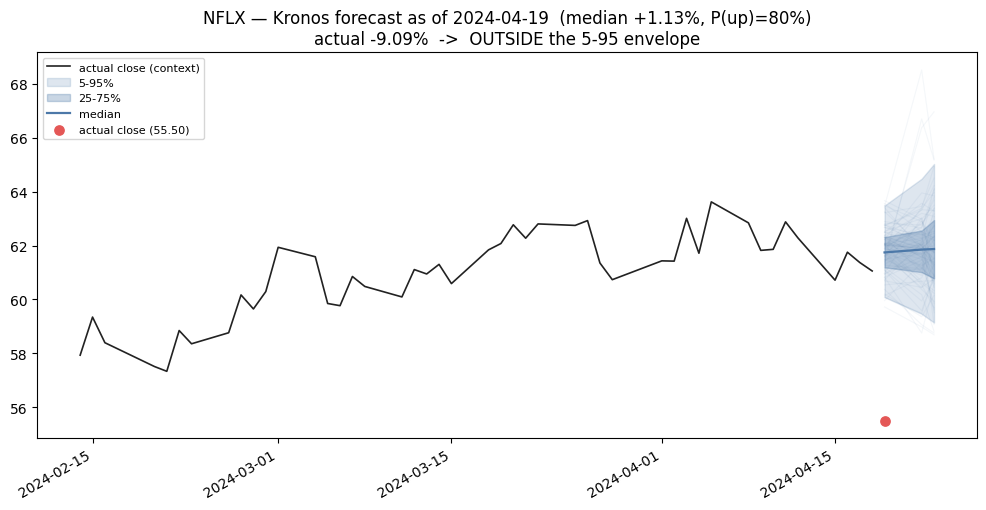

In [8]:
_ = fan_chart(fc, actual_close=a.actual_close, context_bars=45)
plt.gca().set_title(plt.gca().get_title() +
    f"\nactual {a.ret*100:+.2f}%  ->  {'inside' if row['inside_envelope'] else 'OUTSIDE'} the 5-95 envelope")

## 7 · Reading

### Reading this case

NFLX closed **−9.1%** (grade cell above). Both signals missed it:

- **Narrative** returned *bull, conviction 7*. The scorer's own rationale names
  the "stop reporting subscriber counts from 2025" line and the light Q2 guide as
  offsets — and then concludes "the magnitude of the beat should dominate." It
  reasoned about the exact factor that sank the stock and still called it wrong.
  This is what a narrative head-fake looks like: the news genuinely was good, the
  market had already bought it, and the fine print mattered more than the beat.
- **Structure** leaned *bull, +1.1% median*, because NFLX had been trending up
  and Kronos extrapolates. The actual −9.1% landed **below the 5th percentile** of
  its envelope — a clean coverage failure.

No divergence here (both bullish), so no divergence-outcome row — but the
direction-hit and envelope-coverage stats both take the hit. The pilot lesson:
raw narrative conviction has to be discounted when the news is loud and
one-sided, and Kronos's envelope is not wide enough to cover a gap-down driven by
information it never saw.


*(the numbers above are filled from this run; the narrative take assumes the real LLM scorer — re-run with `ANTHROPIC_API_KEY` set if you see `[MOCK]`.)*